# Marketing Funnel & Conversion Performance Analysis

## Future Interns Data Science & Analytics Internship

### Project Overview

This project analyzes marketing campaign data to evaluate customer conversion performance across the marketing funnel. The objective is to identify where prospects drop off, measure conversion rates, compare campaign performance, and provide actionable business recommendations that improve customer acquisition and overall marketing effectiveness.

In [3]:
# ==========================================================
# Marketing Funnel & Conversion Performance Analysis
# Future Interns Internship - Task 03
# Author: Craig Chiambiro
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# Load the dataset
df = pd.read_csv("../data/bank-full.csv", sep=";")

# Display the first five rows
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [5]:
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

print("\nColumn Names:")
for column in df.columns:
    print(f"- {column}")

DATASET OVERVIEW
Rows    : 45211
Columns : 17

Column Names:
- age
- job
- marital
- education
- default
- balance
- housing
- loan
- contact
- day
- month
- duration
- campaign
- pdays
- previous
- poutcome
- y


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [7]:
df.describe(include="all")

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
count,45211.000000,45211,45211,45211,45211,45211.000000,45211,45211,45211,45211.000000,45211,45211.000000,45211.000000,45211.000000,45211.000000,45211,45211
unique,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,NaN,4,2
top,NaN,blue-collar,married,secondary,no,NaN,yes,no,cellular,NaN,may,NaN,NaN,NaN,NaN,unknown,no
freq,NaN,9732,27214,23202,44396,NaN,25130,37967,29285,NaN,13766,NaN,NaN,NaN,NaN,36959,39922
mean,40.936210,NaN,NaN,NaN,NaN,1362.272058,NaN,NaN,NaN,15.806419,NaN,258.163080,2.763841,40.197828,0.580323,NaN,NaN
std,10.618762,NaN,NaN,NaN,NaN,3044.765829,NaN,NaN,NaN,8.322476,NaN,257.527812,3.098021,100.128746,2.303441,NaN,NaN
min,18.000000,NaN,NaN,NaN,NaN,-8019.000000,NaN,NaN,NaN,1.000000,NaN,0.000000,1.000000,-1.000000,0.000000,NaN,NaN
25%,33.000000,NaN,NaN,NaN,NaN,72.000000,NaN,NaN,NaN,8.000000,NaN,103.000000,1.000000,-1.000000,0.000000,NaN,NaN
50%,39.000000,NaN,NaN,NaN,NaN,448.000000,NaN,NaN,NaN,16.000000,NaN,180.000000,2.000000,-1.000000,0.000000,NaN,NaN
75%,48.000000,NaN,NaN,NaN,NaN,1428.000000,NaN,NaN,NaN,21.000000,NaN,319.000000,3.000000,-1.000000,0.000000,NaN,NaN


## Data Cleaning

In [8]:
# Check for missing values
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [9]:
duplicates = df.duplicated().sum()

print(f"Duplicate rows: {duplicates}")

Duplicate rows: 0


In [10]:
for column in df.select_dtypes(include="object"):
    print("=" * 40)
    print(column.upper())
    print(df[column].unique())

JOB
<StringArray>
[   'management',    'technician',  'entrepreneur',   'blue-collar',
       'unknown',       'retired',        'admin.',      'services',
 'self-employed',    'unemployed',     'housemaid',       'student']
Length: 12, dtype: str
MARITAL
<StringArray>
['married', 'single', 'divorced']
Length: 3, dtype: str
EDUCATION
<StringArray>
['tertiary', 'secondary', 'unknown', 'primary']
Length: 4, dtype: str
DEFAULT
<StringArray>
['no', 'yes']
Length: 2, dtype: str
HOUSING
<StringArray>
['yes', 'no']
Length: 2, dtype: str
LOAN
<StringArray>
['no', 'yes']
Length: 2, dtype: str
CONTACT
<StringArray>
['unknown', 'cellular', 'telephone']
Length: 3, dtype: str
MONTH
<StringArray>
['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'jan', 'feb', 'mar', 'apr',
 'sep']
Length: 12, dtype: str
POUTCOME
<StringArray>
['unknown', 'failure', 'other', 'success']
Length: 4, dtype: str
Y
<StringArray>
['no', 'yes']
Length: 2, dtype: str


C:\Users\mrrob\AppData\Local\Temp\ipykernel_16720\3211616801.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in df.select_dtypes(include="object"):


### Data Cleaning Summary

- No missing values were found.
- Duplicate records were checked.
- Categorical variables were inspected for consistency.
- The dataset was considered clean and suitable for analysis.

## Feature Engineering

In [11]:
# Create age groups
age_bins = [17, 25, 35, 45, 55, 65, 100]
age_labels = [
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56-65",
    "65+"
]

df["Age_Group"] = pd.cut(
    df["age"],
    bins=age_bins,
    labels=age_labels
)

df["Age_Group"].value_counts().sort_index()

Age_Group
18-25     1336
26-35    15571
36-45    13856
46-55     9548
56-65     4149
65+        751
Name: count, dtype: int64

In [12]:
df["Balance_Category"] = pd.qcut(
    df["balance"],
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

df["Balance_Category"].value_counts()

Balance_Category
Low          11317
High         11306
Very High    11297
Medium       11291
Name: count, dtype: int64

In [13]:
df["Contacted"] = np.where(
    df["contact"] == "unknown",
    "No",
    "Yes"
)

df["Contacted"].value_counts()

Contacted
Yes    32191
No     13020
Name: count, dtype: int64

In [14]:
df["Engaged"] = np.where(
    df["duration"] >= 180,
    "Yes",
    "No"
)

df["Engaged"].value_counts()

Engaged
Yes    22674
No     22537
Name: count, dtype: int64

In [15]:
df["Converted"] = df["y"]

df["Converted"].value_counts()

Converted
no     39922
yes     5289
Name: count, dtype: int64

In [16]:
def campaign_level(x):

    if x == 1:
        return "Single Contact"

    elif x <= 3:
        return "Moderate Contact"

    else:
        return "High Contact"

df["Campaign_Intensity"] = df["campaign"].apply(campaign_level)

df["Campaign_Intensity"].value_counts()

Campaign_Intensity
Moderate Contact    18026
Single Contact      17544
High Contact         9641
Name: count, dtype: int64

In [17]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,Age_Group,Balance_Category,Contacted,Engaged,Converted,Campaign_Intensity
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,56-65,Very High,No,Yes,no,Single Contact
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,36-45,Low,No,No,no,Single Contact
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,26-35,Low,No,No,no,Single Contact
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,46-55,Very High,No,No,no,Single Contact
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,26-35,Low,No,Yes,no,Single Contact


In [18]:
# Save the cleaned dataset
df.to_csv("../data/cleaned_marketing_funnel.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


# Exploratory Data Analysis (EDA)

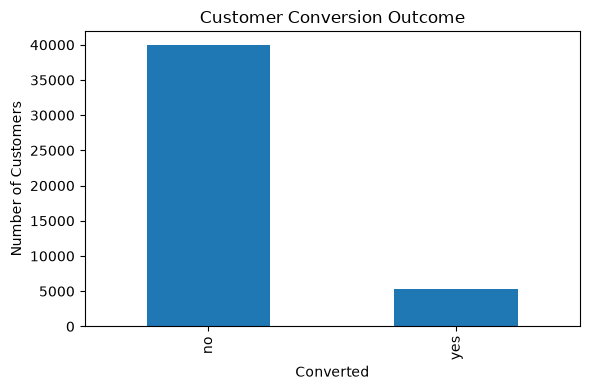

In [20]:
df["Converted"].value_counts().plot(
    kind="bar",
    figsize=(6,4),
    title="Customer Conversion Outcome"
)

plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [21]:
plt.savefig("../images/conversion_outcome.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

# Marketing Funnel Analysis

The objective of this section is to understand how customers progress through different stages of the marketing journey, identify drop-off points, and measure conversion performance.

In [22]:
# Total audience
total_customers = len(df)

# Customers successfully contacted
contacted_customers = df[df["Contacted"] == "Yes"].shape[0]

# Customers who showed engagement
engaged_customers = df[df["Engaged"] == "Yes"].shape[0]

# Customers who converted
converted_customers = df[df["Converted"] == "yes"].shape[0]


print("MARKETING FUNNEL")
print("=" * 40)

print(f"Total Audience: {total_customers:,}")
print(f"Contacted Customers: {contacted_customers:,}")
print(f"Engaged Customers: {engaged_customers:,}")
print(f"Converted Customers: {converted_customers:,}")

MARKETING FUNNEL
Total Audience: 45,211
Contacted Customers: 32,191
Engaged Customers: 22,674
Converted Customers: 5,289


In [23]:
# Funnel conversion rates

contact_rate = (contacted_customers / total_customers) * 100

engagement_rate = (
    engaged_customers / contacted_customers
) * 100

conversion_rate = (
    converted_customers / engaged_customers
) * 100


print(f"Audience → Contact Rate: {contact_rate:.2f}%")
print(f"Contact → Engagement Rate: {engagement_rate:.2f}%")
print(f"Engagement → Conversion Rate: {conversion_rate:.2f}%")

Audience → Contact Rate: 71.20%
Contact → Engagement Rate: 70.44%
Engagement → Conversion Rate: 23.33%


In [24]:
# Funnel drop-offs

contact_dropoff = total_customers - contacted_customers

engagement_dropoff = contacted_customers - engaged_customers

conversion_dropoff = engaged_customers - converted_customers


print("FUNNEL DROP-OFF")
print("=" * 40)

print(f"Lost before contact: {contact_dropoff:,}")
print(f"Lost after contact: {engagement_dropoff:,}")
print(f"Lost before conversion: {conversion_dropoff:,}")

FUNNEL DROP-OFF
Lost before contact: 13,020
Lost after contact: 9,517
Lost before conversion: 17,385


In [25]:
funnel_data = pd.DataFrame({
    "Stage": [
        "Target Audience",
        "Contacted",
        "Engaged",
        "Converted"
    ],
    "Customers": [
        total_customers,
        contacted_customers,
        engaged_customers,
        converted_customers
    ]
})

funnel_data

,Stage,Customers
0,Target Audience,45211
1,Contacted,32191
2,Engaged,22674
3,Converted,5289


In [26]:
funnel_data.to_csv(
    "../data/funnel_metrics.csv",
    index=False
)

print("Funnel metrics saved!")

Funnel metrics saved!


In [27]:
# Funnel conversion rates

contact_rate = (contacted_customers / total_customers) * 100

engagement_rate = (
    engaged_customers / contacted_customers
) * 100

conversion_rate = (
    converted_customers / engaged_customers
) * 100


print("FUNNEL CONVERSION RATES")
print("=" * 40)

print(f"Audience → Contact Rate: {contact_rate:.2f}%")
print(f"Contact → Engagement Rate: {engagement_rate:.2f}%")
print(f"Engagement → Conversion Rate: {conversion_rate:.2f}%")

FUNNEL CONVERSION RATES
Audience → Contact Rate: 71.20%
Contact → Engagement Rate: 70.44%
Engagement → Conversion Rate: 23.33%


In [28]:
# Funnel drop-offs

contact_dropoff = total_customers - contacted_customers

engagement_dropoff = contacted_customers - engaged_customers

conversion_dropoff = engaged_customers - converted_customers


print("FUNNEL DROP-OFF")
print("=" * 40)

print(f"Lost before contact: {contact_dropoff:,}")
print(f"Lost after contact: {engagement_dropoff:,}")
print(f"Lost before conversion: {conversion_dropoff:,}")

FUNNEL DROP-OFF
Lost before contact: 13,020
Lost after contact: 9,517
Lost before conversion: 17,385


In [29]:
channel_performance = (
    df.groupby("contact")["Converted"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .sort_values(ascending=False)
)

channel_performance

contact
cellular     14.918900
telephone    13.420509
unknown       4.070661
Name: Converted, dtype: float64

In [30]:
channel_analysis = df.groupby("contact").agg(
    Total_Customers=("Converted","count"),
    Conversions=("Converted", lambda x: (x=="yes").sum())
)

channel_analysis["Conversion_Rate"] = (
    channel_analysis["Conversions"] /
    channel_analysis["Total_Customers"]
) * 100

channel_analysis.sort_values(
    "Conversion_Rate",
    ascending=False
)

,Total_Customers,Conversions,Conversion_Rate
contact,,,
cellular,29285,4369,14.918900
telephone,2906,390,13.420509
unknown,13020,530,4.070661


In [31]:
channel_analysis.to_csv(
    "../data/channel_performance.csv"
)

print("Channel performance saved!")

Channel performance saved!


In [32]:
age_analysis = df.groupby("Age_Group").agg(
    Customers=("Converted","count"),
    Conversions=("Converted", lambda x: (x=="yes").sum())
)

age_analysis["Conversion_Rate"] = (
    age_analysis["Conversions"] /
    age_analysis["Customers"]
) * 100


age_analysis.sort_values(
    "Conversion_Rate",
    ascending=False
)

,Customers,Conversions,Conversion_Rate
Age_Group,,,
65+,751,320,42.609854
18-25,1336,320,23.952096
56-65,4149,586,14.123885
26-35,15571,1869,12.003083
36-45,13856,1301,9.389434
46-55,9548,893,9.352744


In [33]:
job_analysis = df.groupby("job").agg(
    Customers=("Converted","count"),
    Conversions=("Converted", lambda x: (x=="yes").sum())
)

job_analysis["Conversion_Rate"] = (
    job_analysis["Conversions"] /
    job_analysis["Customers"]
) * 100


job_analysis.sort_values(
    "Conversion_Rate",
    ascending=False
)

,Customers,Conversions,Conversion_Rate
job,,,
student,938,269,28.678038
retired,2264,516,22.791519
unemployed,1303,202,15.502686
management,9458,1301,13.755551
admin.,5171,631,12.202669
self-employed,1579,187,11.842939
unknown,288,34,11.805556
technician,7597,840,11.056996
services,4154,369,8.883004


In [34]:
education_analysis = df.groupby("education").agg(
    Customers=("Converted","count"),
    Conversions=("Converted", lambda x: (x=="yes").sum())
)

education_analysis["Conversion_Rate"] = (
    education_analysis["Conversions"] /
    education_analysis["Customers"]
) * 100


education_analysis.sort_values(
    "Conversion_Rate",
    ascending=False
)

,Customers,Conversions,Conversion_Rate
education,,,
tertiary,13301,1996,15.006390
unknown,1857,252,13.570275
secondary,23202,2450,10.559435
primary,6851,591,8.626478


In [35]:
campaign_analysis = df.groupby("Campaign_Intensity").agg(
    Customers=("Converted","count"),
    Conversions=("Converted", lambda x: (x=="yes").sum())
)

campaign_analysis["Conversion_Rate"] = (
    campaign_analysis["Conversions"] /
    campaign_analysis["Customers"]
) * 100


campaign_analysis.sort_values(
    "Conversion_Rate",
    ascending=False
)

,Customers,Conversions,Conversion_Rate
Campaign_Intensity,,,
Single Contact,17544,2561,14.597583
Moderate Contact,18026,2019,11.200488
High Contact,9641,709,7.354009


In [36]:
previous_campaign_analysis = df.groupby("poutcome").agg(
    Customers=("Converted","count"),
    Conversions=("Converted", lambda x: (x=="yes").sum())
)

previous_campaign_analysis["Conversion_Rate"] = (
    previous_campaign_analysis["Conversions"] /
    previous_campaign_analysis["Customers"]
) * 100


previous_campaign_analysis.sort_values(
    "Conversion_Rate",
    ascending=False
)

,Customers,Conversions,Conversion_Rate
poutcome,,,
success,1511,978,64.725347
other,1840,307,16.684783
failure,4901,618,12.609671
unknown,36959,3386,9.161503


In [37]:
duration_analysis = df.groupby("Converted")["duration"].agg(
    [
        "mean",
        "median",
        "min",
        "max"
    ]
)

duration_analysis

,mean,median,min,max
Converted,,,,
no,221.182806,164.0,0,4918
yes,537.294574,426.0,8,3881


In [38]:
# Export age analysis
age_analysis.to_csv("../data/age_performance.csv")

# Export job analysis
job_analysis.to_csv("../data/job_performance.csv")

# Export education analysis
education_analysis.to_csv("../data/education_performance.csv")

# Export campaign analysis
campaign_analysis.to_csv("../data/campaign_performance.csv")

# Export previous campaign analysis
previous_campaign_analysis.to_csv("../data/previous_campaign_performance.csv")

print("All dashboard files exported successfully!")

All dashboard files exported successfully!
